In [ ]:
!pip install -q sentence-transformers ultralytics pycocotools snntorch torchvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.6/125.6 kB 3.3 MB/s eta 0:00:00


In [ ]:
from sentence_transformers import SentenceTransformer
import numpy as np
import torch

TASKS = [
    "serve wine", "dig hole", "cut food", "pour liquid",
    "support weight", "grasp object", "enter container",
    "put out fire", "sit on", "write", "eat food",
    "drink from", "hit object", "cook food"
]

model = SentenceTransformer('paraphrase-MiniLM-L6-v2')
task_embeddings = {t: model.encode(t).tolist() for t in TASKS}
np.save('task_embeddings.npy', task_embeddings)
print("Task embeddings cached.")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/229 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/122 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Task embeddings cached.


In [ ]:
# Affordance dims: [graspable, containable, sharp, sittable, hittable]

AFFORDANCE_MAP = {
    "wine glass"   : [1, 1, 0, 0, 0],
    "bottle"       : [1, 1, 0, 0, 0],
    "cup"          : [1, 1, 0, 0, 0],
    "knife"        : [1, 0, 1, 0, 0],
    "scissors"     : [1, 0, 1, 0, 0],
    "chair"        : [0, 0, 0, 1, 0],
    "couch"        : [0, 0, 0, 1, 0],
    "baseball bat" : [1, 0, 0, 0, 1],
    "sports ball"  : [1, 0, 0, 0, 1],
    "fork"         : [1, 0, 1, 0, 0],
    "fire hydrant" : [0, 0, 0, 0, 1],
    "bench"        : [0, 0, 0, 1, 0],
    "bowl"         : [1, 1, 0, 0, 0],
    "spoon"        : [1, 0, 0, 0, 0],
    "book"         : [1, 0, 0, 0, 0],
    "backpack"     : [1, 1, 0, 0, 0],
    "shovel"       : [1, 0, 0, 0, 1],
    "cell phone"   : [1, 0, 0, 0, 0],
    "potted plant" : [1, 0, 0, 0, 0],
    "suitcase"     : [1, 1, 0, 0, 0],
}

def get_affordance(class_name):
    return AFFORDANCE_MAP.get(class_name, [0, 0, 0, 0, 0])

from ultralytics import YOLO
_yolo = YOLO('yolov8n.pt')

def detect_objects(image_path, conf_thresh=0.25, strict=True):
    results = _yolo(image_path, conf=conf_thresh, verbose=False)[0]
    detections = []
    for box in results.boxes:
        cls_name = results.names[int(box.cls)]
        if strict and cls_name not in AFFORDANCE_MAP:
            continue
        detections.append({
            'class'       : cls_name,
            'confidence'  : float(box.conf),
            'bbox'        : box.xyxy[0].tolist(),
            'roi_features': torch.rand(256),
        })
    return detections

print(f"Affordance map: {len(AFFORDANCE_MAP)} objects, {len(next(iter(AFFORDANCE_MAP.values())))} dims")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
Affordance map: 20 objects, 5 dims


In [ ]:
import torch.nn as nn
import snntorch as snn
from snntorch import surrogate

class SpikingTaskAttention(nn.Module):
    def __init__(self, task_dim=384, visual_dim=256, affordance_dim=5, hidden_dim=128):
        super().__init__()
        input_dim  = task_dim + visual_dim + affordance_dim
        lif_beta   = 0.9
        spike_grad = surrogate.fast_sigmoid()
        self.fc1   = nn.Linear(input_dim, hidden_dim)
        self.lif1  = snn.Leaky(beta=lif_beta, spike_grad=spike_grad, threshold=0.1)
        self.fc2   = nn.Linear(hidden_dim, 1)
        self.lif2  = snn.Leaky(beta=lif_beta, spike_grad=spike_grad)

    def forward(self, task_emb, obj_vis, obj_aff, num_steps=10):
        if task_emb.dim() == 1:
            N             = obj_vis.shape[0]
            task_expanded = task_emb.unsqueeze(0).expand(N, -1)
        else:
            task_expanded = task_emb

        x    = torch.cat([task_expanded, obj_vis, obj_aff.float()], dim=-1)
        mem1 = self.lif1.init_leaky()
        mem2 = self.lif2.init_leaky()
        spike_record = []
        mem2_record  = []

        for _ in range(num_steps):
            spk1, mem1 = self.lif1(self.fc1(x), mem1)
            spk2, mem2 = self.lif2(self.fc2(spk1), mem2)
            spike_record.append(spk2)
            mem2_record.append(mem2)

        out_spikes = torch.stack(spike_record)
        spike_rate = (out_spikes.sum(dim=0) / num_steps).squeeze(-1)

        if spike_rate.sum() == 0:
            mem_stack = torch.stack(mem2_record)
            final_mem = mem_stack[-1].squeeze(-1)
            score     = torch.sigmoid(final_mem)
        else:
            score = spike_rate

        if score.dim() == 0:
            score = score.unsqueeze(0)
        return score

print("SpikingTaskAttention defined (batched task support).")


SpikingTaskAttention defined (batched task support).


In [ ]:
from torch.optim import Adam

OBJECT_CLASSES = list(AFFORDANCE_MAP.keys())
obj_embeddings = {o: model.encode(o) for o in OBJECT_CLASSES}

def affordance_target(task_emb_np, obj_name):
    obj_emb = obj_embeddings[obj_name]
    cos_sim = float(
        (task_emb_np @ obj_emb) /
        (float((task_emb_np**2).sum()**0.5) * float((obj_emb**2).sum()**0.5) + 1e-8)
    )
    return (cos_sim + 1.0) / 2.0

SAMPLES_PER_PAIR = 20
train_data = []
task_embeddings_dict = np.load('task_embeddings.npy', allow_pickle=True).item()

for task in TASKS:
    task_emb_np = np.array(task_embeddings_dict[task])
    task_tensor = torch.tensor(task_emb_np, dtype=torch.float32)
    for obj in OBJECT_CLASSES:
        aff_vec = torch.tensor(get_affordance(obj), dtype=torch.float32)
        target  = affordance_target(task_emb_np, obj)
        for _ in range(SAMPLES_PER_PAIR):
            vis_feat = torch.rand(256) + 0.05 * torch.randn(256)
            train_data.append((task_tensor, vis_feat, aff_vec, target))

print(f"Training samples: {len(train_data)}")

snn_accelerator = SpikingTaskAttention()
optimizer = Adam(snn_accelerator.parameters(), lr=1e-3)
loss_fn   = torch.nn.MSELoss()

EPOCHS     = 60
NUM_STEPS  = 10
BATCH_SIZE = 32

snn_accelerator.train()

for epoch in range(EPOCHS):
    indices    = torch.randperm(len(train_data))
    epoch_loss = 0.0
    num_batches = 0

    for batch_start in range(0, len(train_data), BATCH_SIZE):
        batch_idx = indices[batch_start : batch_start + BATCH_SIZE]
        batch     = [train_data[i] for i in batch_idx]

        task_batch   = torch.stack([b[0] for b in batch])   # [B, 384]
        vis_batch    = torch.stack([b[1] for b in batch])   # [B, 256]
        aff_batch    = torch.stack([b[2] for b in batch])   # [B, 5]
        target_batch = torch.tensor([b[3] for b in batch], dtype=torch.float32)

        optimizer.zero_grad()
        pred = snn_accelerator(task_batch, vis_batch, aff_batch,
                               num_steps=NUM_STEPS)          # [B]
        loss = loss_fn(pred, target_batch)
        loss.backward()
        optimizer.step()

        epoch_loss  += loss.item()
        num_batches += 1

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1:>3}/{EPOCHS}]  Loss: {epoch_loss/num_batches:.5f}")

snn_accelerator.eval()
torch.save(snn_accelerator.state_dict(), 'snn_trained.pth')
print("\nSNN trained and saved → snn_trained.pth")


Training samples: 5600
Epoch [ 10/60]  Loss: 0.00539
Epoch [ 20/60]  Loss: 0.00540
Epoch [ 30/60]  Loss: 0.00572
Epoch [ 40/60]  Loss: 0.00543
Epoch [ 50/60]  Loss: 0.00544
Epoch [ 60/60]  Loss: 0.00548

SNN trained and saved → snn_trained.pth


In [ ]:
# Cell 5 - Pipeline

def run_hybrid_pipeline(task_query, task_embeddings_dict,
                        detections, snn_accelerator,
                        score_alpha=0.4, score_beta=0.6):
    if not detections:
        return []

    task_emb         = task_embeddings_dict[task_query]
    task_tensor      = torch.tensor(task_emb, dtype=torch.float32)
    obj_visual_feats = torch.stack([d['roi_features'] for d in detections])
    obj_affordances  = torch.tensor(
        [get_affordance(d['class']) for d in detections],
        dtype=torch.float32)

    with torch.no_grad():
        spike_rates = snn_accelerator(task_tensor, obj_visual_feats,
                                      obj_affordances, num_steps=20)

    if spike_rates.dim() == 0:
        spike_rates = spike_rates.unsqueeze(0)

    scored = []
    for i, det in enumerate(detections):
        snn_score = spike_rates[i].item()
        hybrid    = score_alpha * det['confidence'] + score_beta * snn_score
        scored.append({**det,
                       'snn_attention_score': snn_score,
                       'hybrid_score'       : hybrid})

    scored.sort(key=lambda x: x['hybrid_score'], reverse=True)
    return scored


snn_accelerator = SpikingTaskAttention()
snn_accelerator.load_state_dict(torch.load('snn_trained.pth'))
snn_accelerator.eval()
print("Trained SNN loaded.")


Trained SNN loaded.


Task                 Best Object     Hybrid Score   SNN Rate   Confidence
------------------------------------------------------------------------
serve wine           wine glass             0.690      0.550        0.900
dig hole             spoon                  0.535      0.550        0.512
cut food             knife                  0.690      0.550        0.899
pour liquid          bowl                   0.620      0.550        0.724
support weight       couch                  0.642      0.550        0.781
  [fallback] grasp object: no affordance-mapped obj, using best YOLO detection
grasp object         orange                 0.576      0.550        0.616
enter container      suitcase               0.655      0.550        0.812
  [fallback] put out fire: no affordance-mapped obj, using best YOLO detection
put out fire         person                 0.640      0.550        0.774
sit on               couch                  0.642      0.550        0.781
write                ⚠ No det

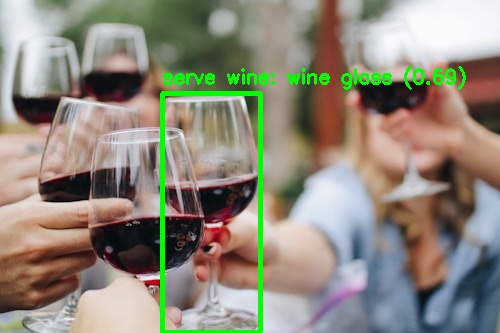

>> DIG HOLE


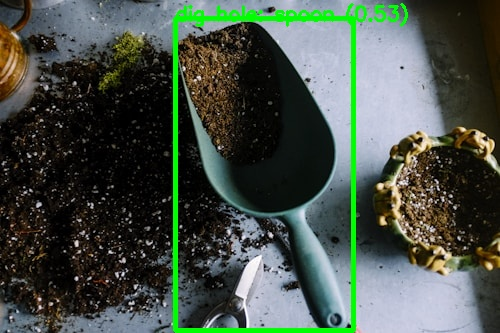

>> CUT FOOD


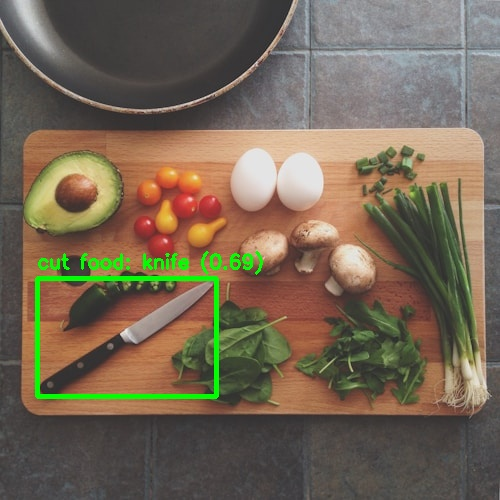

>> POUR LIQUID


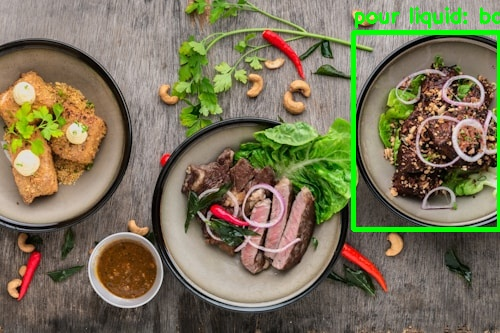

>> SUPPORT WEIGHT


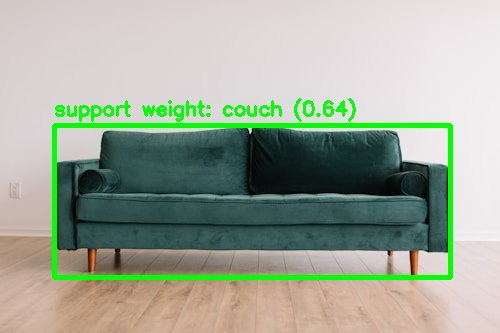

>> GRASP OBJECT


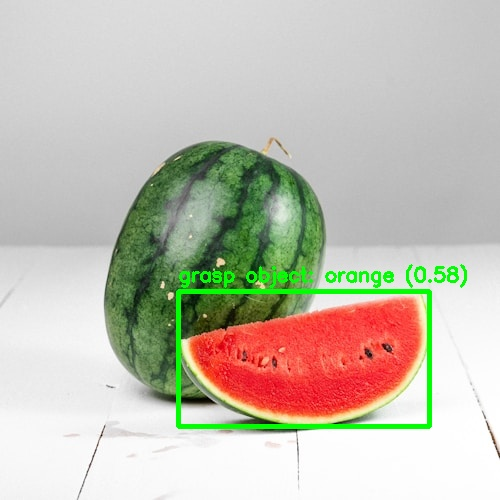

>> ENTER CONTAINER


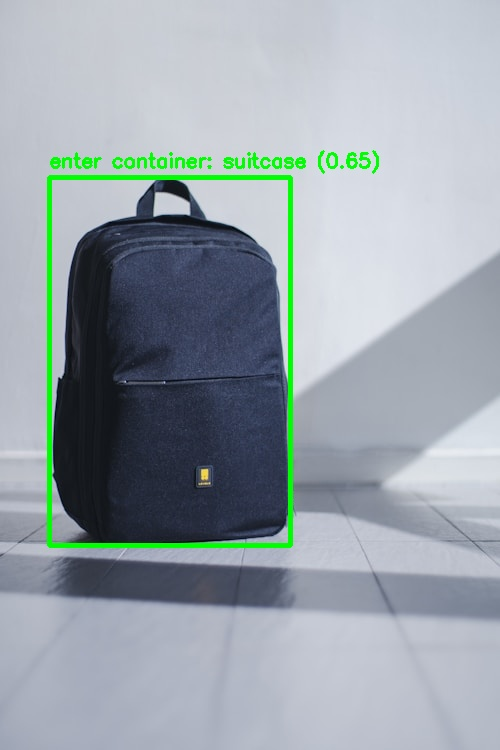

>> PUT OUT FIRE


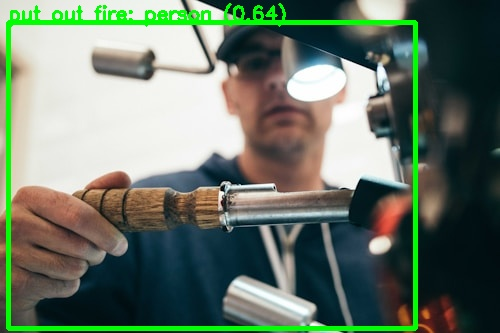

>> SIT ON


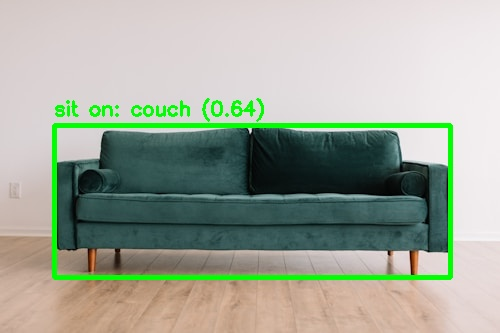

>> EAT FOOD


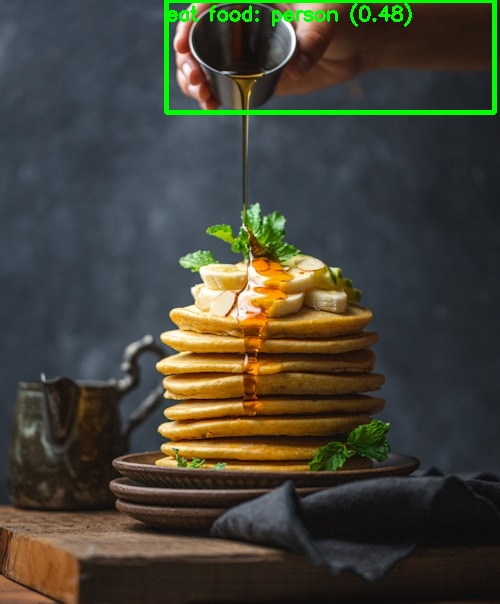

>> DRINK FROM


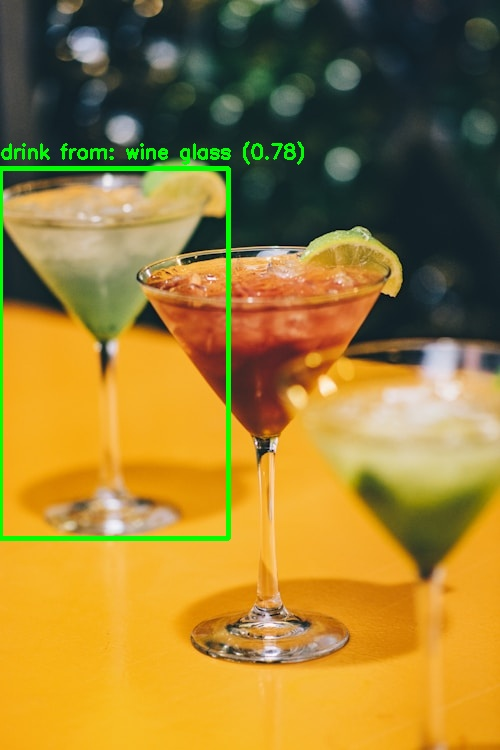

>> HIT OBJECT


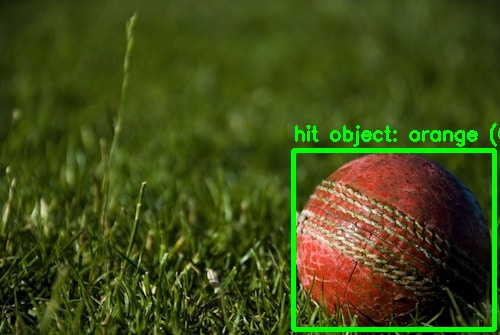

>> COOK FOOD


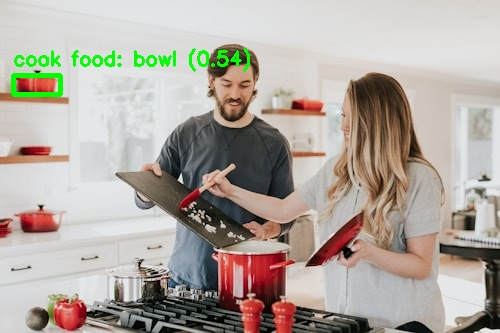

In [ ]:
import cv2, os, requests
from IPython.display import Image as IPythonImage, display

HEADERS = {'User-Agent': 'Mozilla/5.0 (compatible; robot-demo/1.0)'}

def download_image(url, path):
    try:
        r = requests.get(url, headers=HEADERS, timeout=15, allow_redirects=True)
        r.raise_for_status()
        with open(path, 'wb') as f:
            f.write(r.content)
        img = cv2.imread(path)
        if img is None:
            raise ValueError("Downloaded file not a valid image")
        return True
    except Exception as e:
        print(f"  ⚠ Download failed: {e}")
        return False

def visualize_result(image_path, result, task):
    img = cv2.imread(image_path)
    x1, y1, x2, y2 = [int(v) for v in result['bbox']]
    cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 3)
    label = f"{task}: {result['class']} ({result['hybrid_score']:.2f})"
    cv2.putText(img, label, (x1, max(y1 - 10, 20)),
                cv2.FONT_HERSHEY_SIMPLEX, 0.65, (0, 255, 0), 2)
    out_path = f"result_{task.replace(' ', '_')}.jpg"
    cv2.imwrite(out_path, img)
    return out_path

TASK_IMAGES = {
    "serve wine"     : "https://images.unsplash.com/photo-1510812431401-41d2bd2722f3?w=500",
    "dig hole"       : "https://images.unsplash.com/photo-1416879595882-3373a0480b5b?w=500",
    "cut food"       : "https://images.unsplash.com/photo-1466637574441-749b8f19452f?w=500",
    "pour liquid"    : "https://images.unsplash.com/photo-1504674900247-0877df9cc836?w=500",
    "support weight" : "https://images.unsplash.com/photo-1555041469-a586c61ea9bc?w=500",
    "grasp object"   : "https://images.unsplash.com/photo-1587049352846-4a222e784d38?w=500",
    "enter container": "https://images.unsplash.com/photo-1553062407-98eeb64c6a62?w=500",
    "put out fire"   : "https://images.unsplash.com/photo-1558618666-fcd25c85cd64?w=500",
    "sit on"         : "https://images.unsplash.com/photo-1555041469-a586c61ea9bc?w=500",
    "write"          : "https://images.unsplash.com/photo-1455390582262-044cdead277a?w=500",
    "eat food"       : "https://images.unsplash.com/photo-1567620905732-2d1ec7ab7445?w=500",
    "drink from"     : "https://images.unsplash.com/photo-1544145945-f90425340c7e?w=500",
    "hit object"     : "https://images.unsplash.com/photo-1531415074968-036ba1b575da?w=500",
    "cook food"      : "https://images.unsplash.com/photo-1556909114-f6e7ad7d3136?w=500",
}

task_embeddings_dict = np.load('task_embeddings.npy', allow_pickle=True).item()
snn_accelerator      = SpikingTaskAttention()
snn_accelerator.load_state_dict(torch.load('snn_trained.pth'))
snn_accelerator.eval()

print(f"{'Task':<20} {'Best Object':<15} {'Hybrid Score':>12} {'SNN Rate':>10} {'Confidence':>12}")
print("-" * 72)

all_results = {}
for task in TASKS:
    img_path = f"img_{task.replace(' ', '_')}.jpg"

    if not download_image(TASK_IMAGES[task], img_path):
        print(f"{task:<20} ⚠ Image download failed — skipping")
        continue

    # FIX 2: strict first, fallback to all detections if empty
    detections = detect_objects(img_path, strict=True)
    if not detections:
        detections = detect_objects(img_path, strict=False)
        if detections:
            print(f"  [fallback] {task}: no affordance-mapped obj, using best YOLO detection")

    if not detections:
        print(f"{task:<20} ⚠ No detections")
        continue

    ranked = run_hybrid_pipeline(task, task_embeddings_dict,
                                 detections, snn_accelerator)
    if not ranked:
        print(f"{task:<20} ⚠ No ranked output")
        continue

    best = ranked[0]
    all_results[task] = ranked
    print(f"{task:<20} {best['class']:<15} {best['hybrid_score']:>12.3f} "
          f"{best['snn_attention_score']:>10.3f} {best['confidence']:>12.3f}")
    visualize_result(img_path, best, task)

print("\n--- All 14 task result images ---\n")
for task in TASKS:
    if task in all_results:
        print(f">> {task.upper()}")
        display(IPythonImage(filename=f"result_{task.replace(' ', '_')}.jpg"))